# Machine Learning - Classificação com Naive Bayes
# Previsão de Diabetes em Pacientes

**Disciplina:** Tópicos Especiais em TI

**Técnica:** Aprendizado Supervisionado - Classificação (Naive Bayes)

**Dataset real (Kaggle):** Pima Indians Diabetes Database
Fonte: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

### Informações do conjunto de dados
1. Pregnancies: número de gestações
2. Glucose: concentração de glicose no plasma (teste de tolerância à glicose)
3. BloodPressure: pressão diastólica (mm Hg)
4. SkinThickness: espessura da dobra cutânea do tríceps (mm)
5. Insulin: insulina sérica de 2 horas (mu U/ml)
6. BMI: índice de massa corporal
7. DiabetesPedigreeFunction: função que estima o risco genético de diabetes
8. Age: idade (anos)
9. Outcome: variável alvo (1 = diabético, 0 = não diabético)

### Objetivo
Construir um classificador **Naive Bayes (GaussianNB)** capaz de prever se uma paciente tem
diabetes com base em medidas clínicas.

In [1]:
# Importando os pacotes que serão utilizados
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

## 1. Carga e Exploração dos Dados

In [2]:
df_original = pd.read_csv('diabetes.csv')
df_original.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df_original.shape

(768, 9)

In [4]:
df_original.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### Observação importante sobre os dados

Neste dataset, valores **0 (zero)** em colunas como Glucose, BloodPressure, SkinThickness,
Insulin e BMI não fazem sentido fisiológico — na prática, representam **dados ausentes** que
foram codificados como zero na coleta original. Vamos tratar isso antes de seguir.

In [5]:
colunas_zero_invalido = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in colunas_zero_invalido:
    qtd_zeros = (df_original[col] == 0).sum()
    print(f'{col}: {qtd_zeros} valores zerados ({qtd_zeros/len(df_original)*100:.1f}%)')

Glucose: 5 valores zerados (0.7%)
BloodPressure: 35 valores zerados (4.6%)
SkinThickness: 227 valores zerados (29.6%)
Insulin: 374 valores zerados (48.7%)
BMI: 11 valores zerados (1.4%)


In [6]:
# Substituindo os zeros por NaN e depois imputando pela mediana de cada coluna
df = df_original.copy()
for col in colunas_zero_invalido:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 2. Análise Exploratória

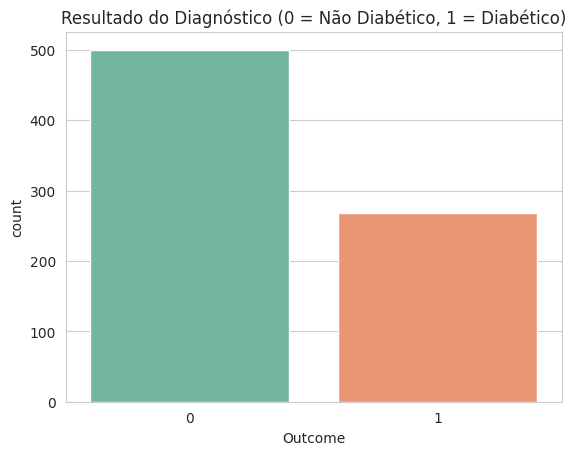

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
# Balanceamento das classes (diagnóstico)
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Resultado do Diagnóstico (0 = Não Diabético, 1 = Diabético)')
plt.show()
df['Outcome'].value_counts()

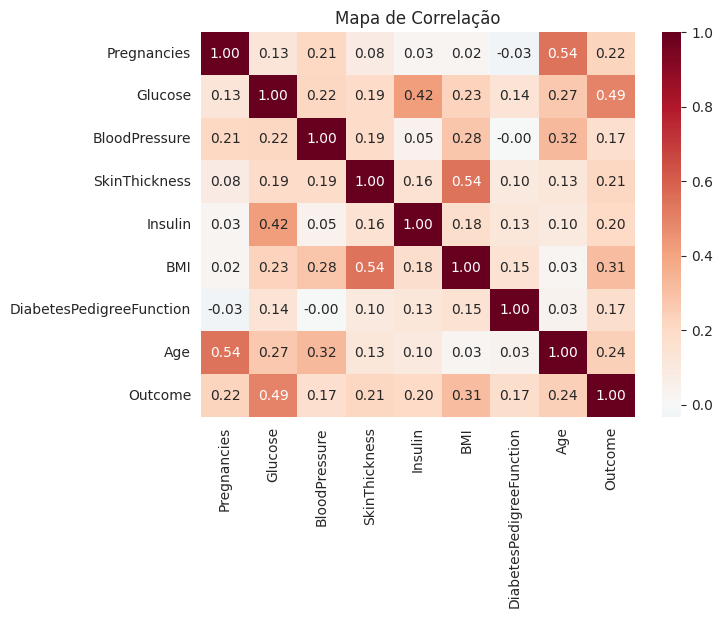

In [8]:
# Correlação entre as variáveis
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Mapa de Correlação')
plt.show()

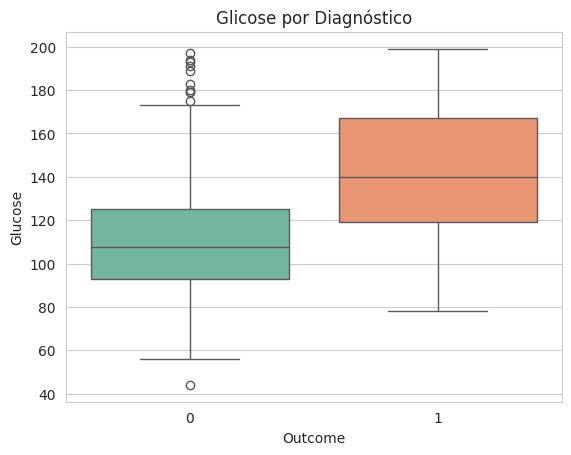

In [9]:
# Distribuição de Glicose por diagnóstico (uma das variáveis mais discriminantes)
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')
plt.title('Glicose por Diagnóstico')
plt.show()

## 3. Preparação dos Dados

In [10]:
# Separa variáveis preditoras (X) e alvo (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train.shape, X_test.shape

((576, 8), (192, 8))

Diferente de modelos baseados em distância ou em árvores, o Naive Bayes Gaussiano não exige
normalização das variáveis — ele assume que cada variável segue uma distribuição normal dentro
de cada classe, então trabalha bem com os dados em sua escala original.

## 4. Treinando o Modelo Naive Bayes

In [11]:
# Treina o modelo Naive Bayes Gaussiano
modelo_NB = GaussianNB()
modelo_NB.fit(X_train, y_train)

y_pred = modelo_NB.predict(X_test)

print('Acurácia:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Não Diabético', 'Diabético']))

Acurácia: 0.7239583333333334
               precision    recall  f1-score   support

Não Diabético       0.80      0.78      0.79       125
    Diabético       0.60      0.63      0.61        67

     accuracy                           0.72       192
    macro avg       0.70      0.70      0.70       192
 weighted avg       0.73      0.72      0.73       192



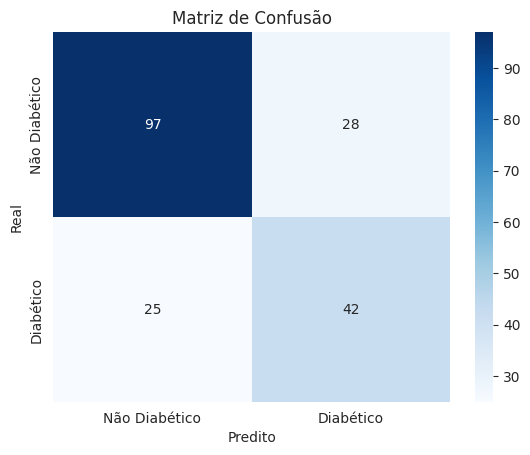

In [12]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Diabético', 'Diabético'], yticklabels=['Não Diabético', 'Diabético'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## 5. Classificando uma Nova Paciente

In [13]:
# Exemplo de nova paciente: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI,
# DiabetesPedigreeFunction, Age
nova_paciente = [[2, 150, 80, 30, 100, 33.5, 0.6, 40]]

res = modelo_NB.predict(nova_paciente)
prob = modelo_NB.predict_proba(nova_paciente)

diagnostico = 'Diabético' if res[0] == 1 else 'Não Diabético'
print(f'Diagnóstico previsto: {diagnostico}')
print(f'Probabilidade [Não Diabético, Diabético]: {prob[0].round(3)}')

Diagnóstico previsto: Diabético
Probabilidade [Não Diabético, Diabético]: [0.498 0.502]


## 6. Conclusão

O classificador Naive Bayes, mesmo com a suposição simplificadora de independência entre as
variáveis, conseguiu um bom desempenho na previsão de diabetes após o tratamento dos valores
ausentes disfarçados de zero. As variáveis **Glucose** e **BMI** seguem sendo as que mais
diferenciam pacientes diabéticos de não diabéticos, o que é coerente com o conhecimento médico
sobre os principais fatores de risco da doença.